Sequential Flow:

Start --> Calculate Area of Rectangle (Length * Breadth) --> End

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [14]:
# Define State
class Area_State(TypedDict):
    length: float
    breadth: float
    area: float

In [18]:
# Define area calculate function
def rectangle_area(state:Area_State)-> Area_State:
    len = state['length']
    bre = state['breadth']

    area = len * bre

    state['area'] = area

    return state

In [19]:
# Define the Graph Flow
graph = StateGraph(Area_State)

# Add node in graph
graph.add_node('rectangle_area',rectangle_area)

# Add edges in graph
graph.add_edge(START,'rectangle_area')
graph.add_edge('rectangle_area',END)

# Compile the graph
workflow = graph.compile()


In [20]:
# Execute the Graph

input = {'length': 120, 'breadth':45}

output = workflow.invoke(input)

print(output)

{'length': 120, 'breadth': 45, 'area': 5400}


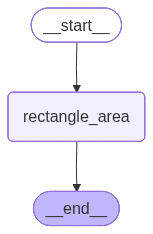

In [22]:
# Display the Graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())